In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [2]:
data_path = Path("../data/processed") / "spy.csv"
if not data_path.exists():
    raise FileNotFoundError(f"{data_path} not found. Expected [data/spy_df.csv](data/spy_df.csv)")

spy_df = pd.read_csv(data_path, index_col=0, parse_dates=True)

C:\Users\mijuu\AppData\Local\Temp\ipykernel_9280\187251524.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  spy_df = pd.read_csv(data_path, index_col=0, parse_dates=True)


In [3]:
data_path = Path("../data/processed") / "bnd.csv"
if not data_path.exists():
    raise FileNotFoundError(f"{data_path} not found. Expected [data/bnd_df.csv](data/bnd_df.csv)")

bnd_df = pd.read_csv(data_path, index_col=0, parse_dates=True)

C:\Users\mijuu\AppData\Local\Temp\ipykernel_9280\4191734478.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  bnd_df = pd.read_csv(data_path, index_col=0, parse_dates=True)


In [4]:
data_path = Path("../data") / "tsla.csv"
if not data_path.exists():
    raise FileNotFoundError(f"{data_path} not found. Expected [data/tsla_df.csv](data/tsla_df.csv)")

# Skip the extra metadata rows in tsla.csv so the header and data align correctly.
tsla_df = pd.read_csv(data_path, skiprows=[1, 2], index_col=0, parse_dates=True)


In [5]:
spy_df = spy_df.reset_index().rename(columns={'index': 'Close'})
bnd_df = bnd_df.reset_index().rename(columns={'index': 'Close'})
tsla_df = tsla_df.reset_index().rename(columns={'index': 'Close'})

In [6]:
prices = pd.DataFrame({
    "TSLA": tsla_df["Close"],
    "SPY": spy_df["Close"],
    "BND": bnd_df["Close"]
})

prices.head()

,TSLA,SPY,BND
0,14.620667,169.687851,59.405445
1,14.006000,166.623306,59.577919
2,14.085333,165.053925,59.750393
3,14.063333,167.110703,59.786343
4,14.041333,170.076096,59.692902


In [7]:
tsla_current_price = prices["TSLA"].iloc[-1]

tsla_expected_return = (
    423.76706 - tsla_current_price
) / tsla_current_price

print(tsla_expected_return)

0.028960430672507902


In [8]:
# ...existing code...
spy_df = spy_df.reset_index().rename(columns={'index': 'Close'})
bnd_df = bnd_df.reset_index().rename(columns={'index': 'Close'})
tsla_df = tsla_df.reset_index().rename(columns={'index': 'Close'})

# check if spy_df and bnd_df are the same
common_cols = spy_df.columns.intersection(bnd_df.columns)
if common_cols.empty:
    print("No common columns to compare")
else:
    s = spy_df[common_cols].reset_index(drop=True)
    b = bnd_df[common_cols].reset_index(drop=True)
    exact = s.equals(b)
    print("Exact equality:", exact)
    if not exact:
        print("First differences (up to 10 rows):")
        print(s.compare(b).head(10))
    num_cols = s.select_dtypes(include=[np.number]).columns
    if len(num_cols):
        approx = np.allclose(s[num_cols].fillna(0).values, b[num_cols].fillna(0).values, atol=1e-8, equal_nan=True)
        print("Numeric approx equal:", approx)
# ...existing code...

Exact equality: False
First differences (up to 10 rows):
        Close                   High                    Low             \
         self      other        self      other        self      other   
0  169.687851  59.405445  170.885580  59.434196  168.655335  59.240128   
1  166.623306  59.577919  168.812235  59.599481  166.317686  59.441353   
2  165.053925  59.750393  167.449357  59.930083  164.260947  59.678518   
3  167.110703  59.786343  167.449371  59.858217  165.929510  59.692906   
4  170.076096  59.692902  170.290867  59.736025  168.498420  59.635400   
5  168.713150  59.793541  170.505597  59.865416  168.101896  59.656975   
6  167.391541  59.872646  169.002276  59.894208  166.788555  59.800766   
7  166.920731  59.930103  169.729170  59.994794  165.623884  59.822294   
8  165.912979  60.066669  166.111227  60.174484  164.021415  60.052297   
9  164.393127  60.332584  166.862898  60.346957  164.277486  60.052269   

         Open                Volume           
       

In [9]:
returns = prices.pct_change().dropna()

In [10]:
returns.head()

,TSLA,SPY,BND
1,-0.042041,-0.018060,0.002903
2,0.005664,-0.009419,0.002895
3,-0.001562,0.012461,0.000602
4,-0.001564,0.017745,-0.001563
5,-0.018802,-0.008014,0.001686


In [11]:
spy_expected_return = returns["SPY"].mean() * 252

bnd_expected_return = returns["BND"].mean() * 252

In [12]:
print("TSLA:", tsla_expected_return)
print("SPY :", spy_expected_return)
print("BND :", bnd_expected_return)

TSLA: 0.028960430672507902
SPY : 0.1443201955786382
BND : 0.019956930571465


In [13]:
expected_returns = pd.Series({
    "TSLA": tsla_expected_return,
    "SPY": spy_expected_return,
    "BND": bnd_expected_return
})

expected_returns

TSLA    0.028960
SPY     0.144320
BND     0.019957
dtype: float64

Covariance Matrix

In [14]:
cov_matrix = returns.cov() * 252

cov_matrix

,TSLA,SPY,BND
TSLA,0.326926,0.049820,0.001803
SPY,0.049820,0.031169,0.001085
BND,0.001803,0.001085,0.002823


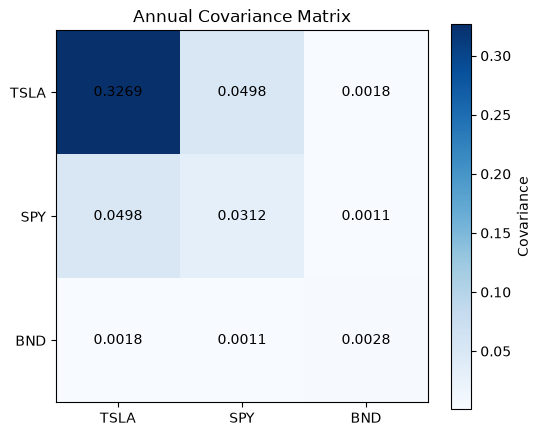

In [15]:
plt.figure(figsize=(6,5))

plt.imshow(cov_matrix, cmap="Blues")

plt.xticks(range(len(cov_matrix.columns)), cov_matrix.columns)
plt.yticks(range(len(cov_matrix.columns)), cov_matrix.columns)

plt.colorbar(label="Covariance")

for i in range(len(cov_matrix)):
    for j in range(len(cov_matrix)):
        plt.text(
            j,
            i,
            f"{cov_matrix.iloc[i,j]:.4f}",
            ha="center",
            va="center",
            color="black"
        )

plt.title("Annual Covariance Matrix")

plt.show()

In [16]:
from pypfopt import EfficientFrontier
from pypfopt import plotting

In [17]:
ef = EfficientFrontier(expected_returns, cov_matrix)

In [18]:
weights = ef.max_sharpe()

clean_weights = ef.clean_weights()

print(clean_weights)

OrderedDict({'TSLA': 0.0, 'SPY': 0.45326, 'BND': 0.54674})


Minimum Volatility Portfolio

In [19]:
from pypfopt import EfficientFrontier

ef_min = EfficientFrontier(expected_returns, cov_matrix)

ef_min.min_volatility()

min_weights = ef_min.clean_weights()

print(min_weights)

ef_min.portfolio_performance(verbose=True)

OrderedDict({'TSLA': 0.0, 'SPY': 0.05462, 'BND': 0.94538})
Expected annual return: 2.7%
Annual volatility: 5.2%
Sharpe Ratio: 0.51


(np.float64(0.026749098903309263),
 np.float64(0.05223450320394838),
 np.float64(0.5120963589692438))

Efficient Frontier

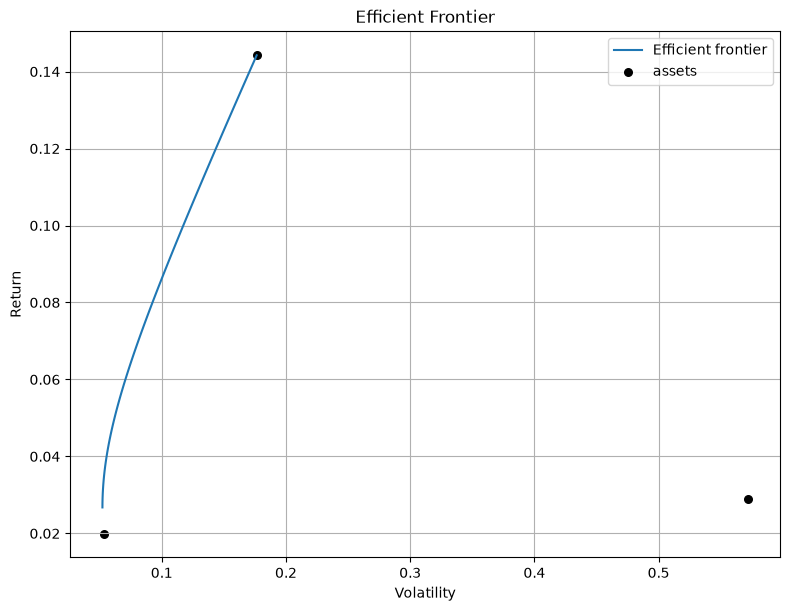

In [20]:
from pypfopt import plotting
import matplotlib.pyplot as plt

ef_plot = EfficientFrontier(expected_returns, cov_matrix)

fig, ax = plt.subplots(figsize=(8,6))

plotting.plot_efficient_frontier(
    ef_plot,
    ax=ax,
    show_assets=True
)

plt.title("Efficient Frontier")
plt.grid(True)
plt.show()

Portfolio Recommendation Table

In [21]:
recommendation = pd.DataFrame({
    "Asset": list(clean_weights.keys()),
    "Weight": list(clean_weights.values())
})

recommendation["Weight (%)"] = recommendation["Weight"] * 100

recommendation

,Asset,Weight,Weight (%)
0,TSLA,0.00000,0.000
1,SPY,0.45326,45.326
2,BND,0.54674,54.674


The Maximum Sharpe Ratio portfolio allocated approximately 45.3% to SPY and 54.7% to BND, while assigning no weight to Tesla. Although Tesla has high growth potential, its forecasted return was not sufficient to compensate for its substantially higher volatility. Consequently, the optimizer favored a diversified allocation between the broad equity market (SPY) and the bond market (BND), resulting in a superior expected risk-adjusted return.